<a href="https://colab.research.google.com/github/Ololade117/stat4datascience/blob/main/SQ4DS_Lecture_6_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistics and Quantitative Methods for Data Science
[© Silvadew Institute](https://institute.silvadew.com/course-details/?c=43177d50)

# Lecture 11.1  Statistical Methods for Machine Learning & Feature Selection
### Statistics & Quantitative Methods for Data Science

Every statistical tool from Weeks 1-4 shows up again inside machine learning — just wearing a different name. This class connects the dots and introduces **feature selection**: using statistics to decide *which* variables are worth feeding into a model.

**This notebook:**
1. Why ML needs statistics: train/test split & the generalization problem
2. Feature scaling — why and how
3. Filter-based feature selection: correlation, ANOVA F-test, chi-square
4. Mutual information
5. A worked feature-selection pipeline
6. Class imbalance, statistically
7. Exercises


## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif, chi2, mutual_info_classif, SelectKBest

np.random.seed(42)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (7, 4)

TITANIC_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
titanic = pd.read_csv(TITANIC_URL)
titanic.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


---
# 1. Why ML needs statistics: the generalization problem

A model that fits training data perfectly can still fail on new data — this is **overfitting**. The **train/test split** directly uses the sampling logic from Week 2: your training set is a *sample*; if a model latches onto quirks of that one sample rather than the true underlying pattern, it won't generalize, exactly like a confidence interval built from a bad sample misses the true population value.

In [ ]:
features = ['pclass', 'age', 'sibsp', 'parch', 'fare']
df = titanic.dropna(subset=features + ['survived']).copy()
X = df[features]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train size: {len(X_train)}   Test size: {len(X_test)}")
print(f"Survival rate -- train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")
print("(stratify=y keeps the class balance the same in both splits -- itself a form of stratified sampling from Week 2!)")

Train size: 571   Test size: 143
Survival rate -- train: 0.406, test: 0.406
(stratify=y keeps the class balance the same in both splits -- itself a form of stratified sampling from Week 2!)


---
# 2. Feature scaling — why and how

Many ML algorithms (e.g. distance-based or gradient-based methods) are sensitive to the **scale** of features. `age` (0-80) and `fare` (0-500+) live on very different scales — without scaling, `fare` would dominate purely due to its larger numbers, not because it's more informative. **Standardization** rescales each feature to the z-score from Week 1: mean 0, std 1.

In [ ]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=features, index=X_train.index)

print("Before scaling:")
print(X_train.describe().loc[['mean', 'std']].round(2))
print("\nAfter scaling:")
print(X_train_scaled.describe().loc[['mean', 'std']].round(2))
print("\n-> Every feature now has mean~0, std~1 -- this IS the z-score formula from Week 1, applied feature-by-feature.")

Before scaling:
      pclass    age  sibsp  parch   fare
mean    2.24  29.33   0.51   0.44  33.70
std     0.84  14.49   0.95   0.87  51.76

After scaling:
      pclass  age  sibsp  parch  fare
mean     0.0 -0.0   -0.0    0.0  -0.0
std      1.0  1.0    1.0    1.0   1.0

-> Every feature now has mean~0, std~1 -- this IS the z-score formula from Week 1, applied feature-by-feature.


> **Important**: the scaler is `fit` on the training data only, then applied (`.transform`) to the test data — fitting on the full dataset would leak test-set information into training, a subtle but common mistake.

---
# 3. Filter-based feature selection

**Filter methods** score each feature's relationship to the target *independently*, using the statistical tests we already know, then keep the top-scoring features.

- **Numeric feature, numeric target**: correlation (Week 4)
- **Numeric feature, categorical target**: ANOVA F-test (Week 3 — same F-statistic!)
- **Categorical feature, categorical target**: chi-square (Week 3)

In [ ]:
# ANOVA F-test: does each numeric feature differ significantly across the two survived classes?
f_scores, p_values = f_classif(X_train, y_train)

f_test_results = pd.DataFrame({'feature': features, 'F-score': f_scores, 'p-value': p_values}) \
    .sort_values('F-score', ascending=False)
print(f_test_results)
print("\n-> Higher F-score = feature means differ more between survived/died -> more useful for classification.")

  feature    F-score       p-value
0  pclass  87.399775  2.005521e-19
4    fare  40.689297  3.698320e-10
3   parch   6.096192  1.383995e-02
1     age   4.466357  3.500330e-02
2   sibsp   0.130501  7.180477e-01

-> Higher F-score = feature means differ more between survived/died -> more useful for classification.


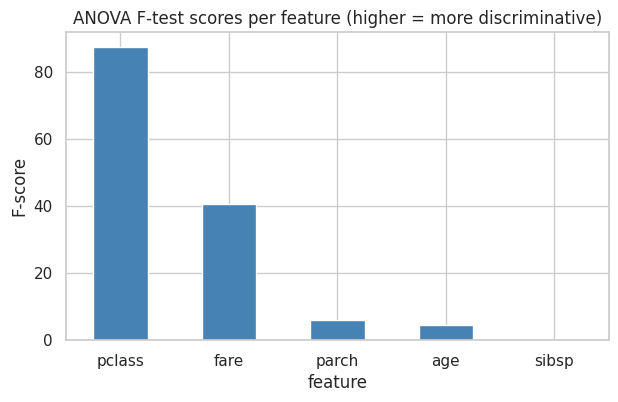

In [ ]:
f_test_results.plot(x='feature', y='F-score', kind='bar', legend=False, color='steelblue')
plt.title('ANOVA F-test scores per feature (higher = more discriminative)')
plt.ylabel('F-score'); plt.xticks(rotation=0)
plt.show()

In [ ]:
# Chi-square needs non-negative values -- appropriate for a categorical feature like pclass, sex
cat_df = titanic.dropna(subset=['pclass', 'sex', 'survived']).copy()
cat_df['sex_code'] = cat_df['sex'].map({'male': 0, 'female': 1})

X_cat = cat_df[['pclass', 'sex_code']]
chi2_scores, chi2_p = chi2(X_cat, cat_df['survived'])
print(pd.DataFrame({'feature': ['pclass', 'sex_code'], 'chi2': chi2_scores, 'p-value': chi2_p}))

    feature        chi2       p-value
0    pclass   30.873699  2.753786e-08
1  sex_code  170.348127  6.210585e-39


---
# 4. Mutual information

Correlation and ANOVA only catch **linear / mean-shift** relationships. **Mutual information** measures *any* kind of statistical dependency (linear or not) between a feature and the target, in bits of shared information — 0 means truly independent.

  feature  mutual_info
4    fare     0.118024
0  pclass     0.091005
1     age     0.030919
3   parch     0.024313
2   sibsp     0.000000


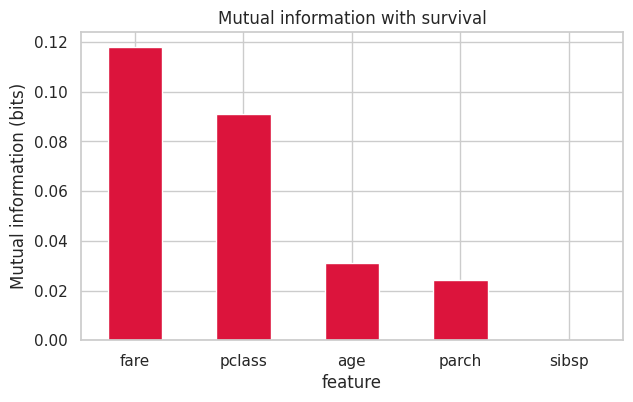

In [ ]:
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_results = pd.DataFrame({'feature': features, 'mutual_info': mi_scores}).sort_values('mutual_info', ascending=False)
print(mi_results)

mi_results.plot(x='feature', y='mutual_info', kind='bar', legend=False, color='crimson')
plt.title('Mutual information with survival')
plt.ylabel('Mutual information (bits)'); plt.xticks(rotation=0)
plt.show()

---
# 5. A worked feature-selection pipeline

`SelectKBest` automates "score every feature, keep the top k" using any of the scoring functions above.

In [ ]:
selector = SelectKBest(score_func=f_classif, k=3)
X_selected = selector.fit_transform(X_train, y_train)

selected_features = X_train.columns[selector.get_support()]
print(f"Top 3 features by ANOVA F-test: {list(selected_features)}")

scores_df = pd.DataFrame({'feature': features, 'score': selector.scores_, 'selected': selector.get_support()})
print(scores_df.sort_values('score', ascending=False))

Top 3 features by ANOVA F-test: ['pclass', 'parch', 'fare']
  feature      score  selected
0  pclass  87.399775      True
4    fare  40.689297      True
3   parch   6.096192      True
1     age   4.466357     False
2   sibsp   0.130501     False


---
# 6. Class imbalance, statistically

If one class dominates (e.g. 90% did-not-survive), a model can get 90% accuracy by *always* predicting the majority class — useless in practice. This connects to Week 3's proportion confidence intervals: with few minority-class examples, any statistic estimated *within* that class has a wide margin of error, so the model has little reliable signal to learn from.

In [ ]:
print("Class balance in full data:")
print(titanic['survived'].value_counts(normalize=True).round(3))

# A wide CI on the minority group illustrates the problem directly
minority = titanic[titanic.survived == 1]
p_hat = minority['pclass'].eq(1).mean()
se = np.sqrt(p_hat*(1-p_hat)/len(minority))
ci = stats.norm.interval(0.95, loc=p_hat, scale=se)
print(f"\nEven WITHIN the survivors (n={len(minority)}), the proportion who were 1st class has a")
print(f"95% CI of [{ci[0]:.3f}, {ci[1]:.3f}] -- a wide range because the group itself is a small subsample.")
print("With even fewer minority-class examples, per-class statistics get even less reliable.")

Class balance in full data:
survived
0    0.616
1    0.384
Name: proportion, dtype: float64

Even WITHIN the survivors (n=342), the proportion who were 1st class has a
95% CI of [0.346, 0.450] -- a wide range because the group itself is a small subsample.
With even fewer minority-class examples, per-class statistics get even less reliable.


---
# 7. Exercises

1. Fit a `StandardScaler` on `X_train`, transform `X_test` with it (not a freshly-fit scaler!), and confirm the *test* set's mean isn't exactly 0 (since the scaler's parameters came only from train).
2. Add `sex_code` (0/1 encoded) to the `features` list and rerun the ANOVA F-test ranking. Where does it land relative to the others?
3. Use `SelectKBest` with `mutual_info_classif` instead of `f_classif`. Does the top-3 feature set change?
4. Using `pd.crosstab`, check the class balance of `survived` within just the 3rd-class passengers. Is it more or less imbalanced than the overall dataset?
5. **Challenge**: Look up `class_weight='balanced'` (available in many scikit-learn classifiers) or the **SMOTE** oversampling technique. In a sentence or two, describe how each statistically addresses the class-imbalance problem from Section 6.


# Lecture 11.2  The Bias-Variance Tradeoff & Regularization
### Statistics & Quantitative Methods for Data Science

Last class's KNN-k and tree-depth sweeps both showed the same shape: a model too simple underperforms, a model too complex also underperforms (on new data), and the best model sits somewhere in between. This class names that phenomenon precisely and gives you the standard statistical tools to control it.

**This notebook:**
1. Underfitting vs. overfitting, defined precisely
2. The bias-variance decomposition
3. Learning curves
4. Regularization: Ridge (L2)
5. Regularization: Lasso (L1) and automatic feature selection
6. ElasticNet & choosing the regularization strength
7. Exercises


## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (7, 4)

TITANIC_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
titanic = pd.read_csv(TITANIC_URL)
df = titanic.dropna(subset=['age','fare','pclass','sibsp','parch']).copy()

---
# 1. Underfitting vs. overfitting, defined precisely

- **Underfitting (high bias)**: the model is too simple to capture the true pattern. It performs poorly on *both* training and test data.
- **Overfitting (high variance)**: the model is complex enough to memorize noise specific to the training sample. It performs great on training data but poorly on test data.

We'll make this concrete with **polynomial regression** on a single feature — polynomial *degree* is a clean, tunable "complexity dial".

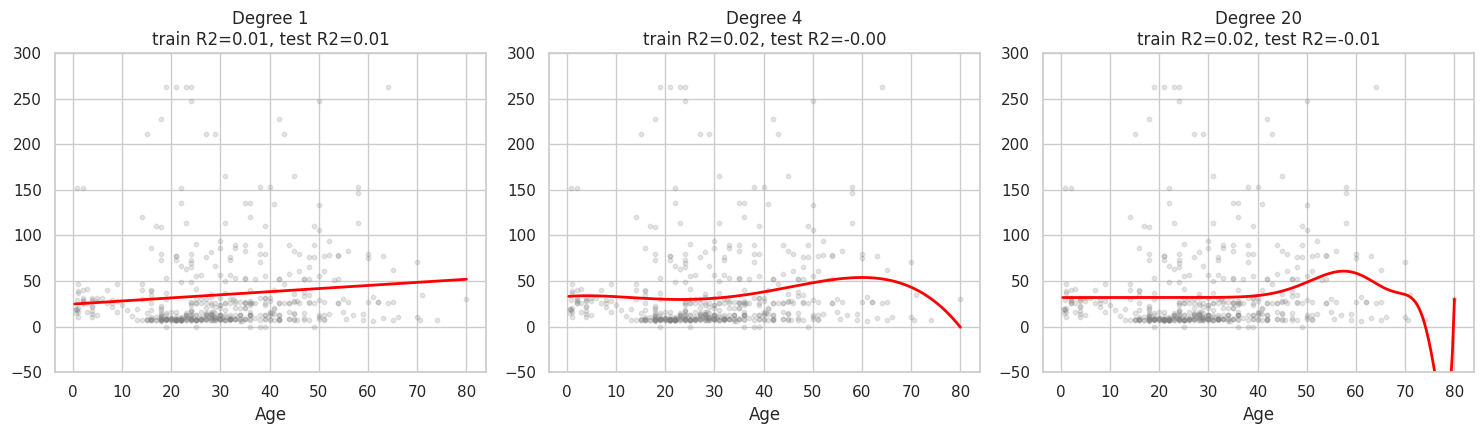

In [ ]:
x = df['age'].to_numpy()
y = df['fare'].to_numpy()
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15,4.5))
for ax, degree in zip(axes, [1, 4, 20]):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(x_train.reshape(-1,1), y_train)

    x_line = np.linspace(x.min(), x.max(), 200).reshape(-1,1)
    y_line = model.predict(x_line)

    train_r2 = r2_score(y_train, model.predict(x_train.reshape(-1,1)))
    test_r2 = r2_score(y_test, model.predict(x_test.reshape(-1,1)))

    ax.scatter(x_train, y_train, alpha=0.2, s=10, color='gray')
    ax.plot(x_line, y_line, color='red', linewidth=2)
    ax.set_ylim(-50, 300)
    ax.set_title(f'Degree {degree}\ntrain R2={train_r2:.2f}, test R2={test_r2:.2f}')
    ax.set_xlabel('Age')
plt.tight_layout()
plt.show()

Degree 1 (a straight line) **underfits** — it's too rigid to capture much structure at all. Degree 20 **overfits** — it wiggles wildly to chase individual training points, and generalizes worse than the simpler degree-4 curve despite a higher *training* R2. This is the central tension of applied statistics and ML: fitting the data you have vs. generalizing to data you haven't seen.

---
# 2. The bias-variance decomposition

For a model's expected squared prediction error, statistical theory decomposes it into three additive pieces:

$$\text{Expected Error} = \underbrace{\text{Bias}^2}_{\text{systematic error from an overly simple model}} + \underbrace{\text{Variance}}_{\text{sensitivity to which training sample you happened to get}} + \underbrace{\text{Irreducible error}}_{\text{noise no model can remove}}$$

We can *see* variance directly: refit the same model on many different random training samples, and watch how much the predictions swing.

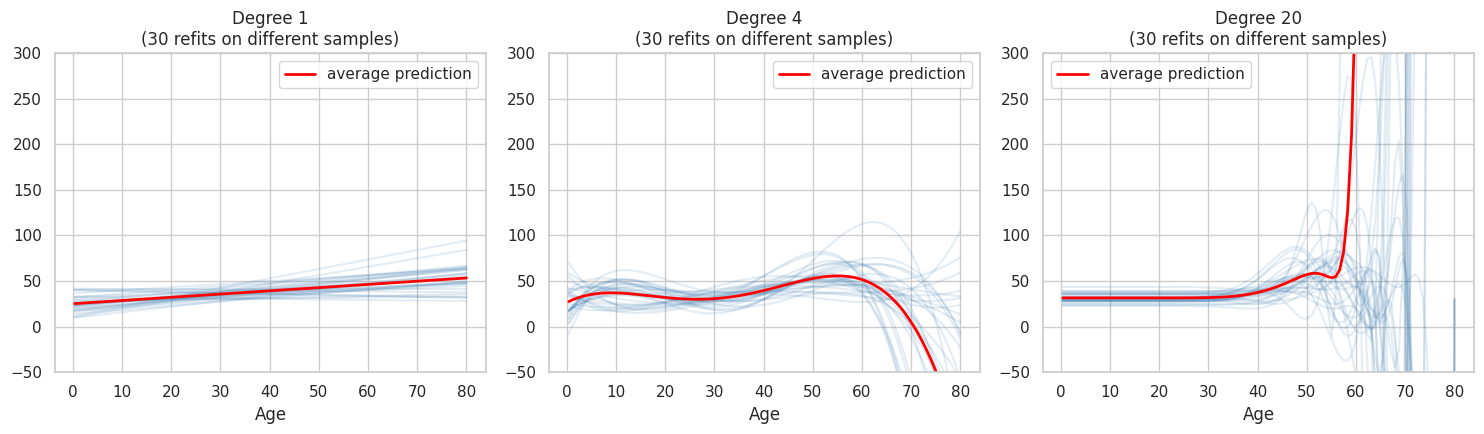

-> Degree 20's spaghetti of wildly different curves per sample IS high variance, visualized directly.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.5))
x_line = np.linspace(x.min(), x.max(), 100).reshape(-1,1)

for ax, degree in zip(axes, [1, 4, 20]):
    predictions = []
    for i in range(30):   # 30 different random samples of the SAME underlying population
        idx = np.random.RandomState(i).choice(len(x_train), size=100, replace=True)
        model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
        model.fit(x_train[idx].reshape(-1,1), y_train[idx])
        preds = model.predict(x_line)
        predictions.append(preds)
        ax.plot(x_line, preds, color='steelblue', alpha=0.15)

    predictions = np.array(predictions)
    ax.plot(x_line, predictions.mean(axis=0), color='red', linewidth=2, label='average prediction')
    ax.set_ylim(-50, 300); ax.set_title(f'Degree {degree}\n(30 refits on different samples)')
    ax.set_xlabel('Age'); ax.legend()
plt.tight_layout()
plt.show()
print("-> Degree 20's spaghetti of wildly different curves per sample IS high variance, visualized directly.")

---
# 3. Learning curves

A **learning curve** plots training and validation error as a function of **training set size** — it diagnoses bias vs. variance directly:
- High bias: both curves plateau at a high error, close together (more data won't help much — the model itself is too simple)
- High variance: a big gap between train and validation error (more data usually *does* help close the gap)

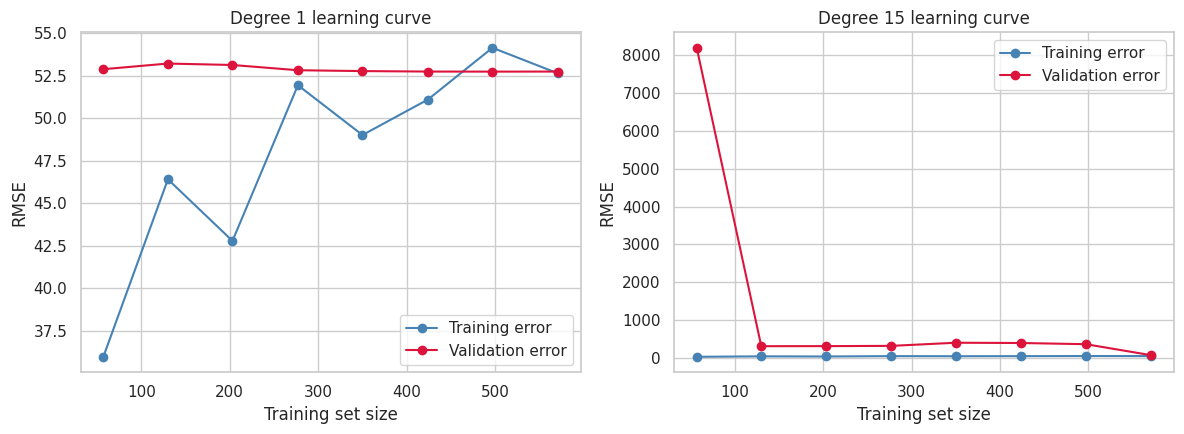

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))

for ax, degree in zip(axes, [1, 15]):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    train_sizes, train_scores, val_scores = learning_curve(
        model, x.reshape(-1,1), y, cv=5, scoring='neg_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 8))

    train_rmse = np.sqrt(-train_scores.mean(axis=1))
    val_rmse = np.sqrt(-val_scores.mean(axis=1))

    ax.plot(train_sizes, train_rmse, marker='o', label='Training error', color='steelblue')
    ax.plot(train_sizes, val_rmse, marker='o', label='Validation error', color='crimson')
    ax.set_xlabel('Training set size'); ax.set_ylabel('RMSE'); ax.legend()
    ax.set_title(f'Degree {degree} learning curve')
plt.tight_layout()
plt.show()

---
# 4. Regularization: Ridge (L2)

**Regularization** fights overfitting directly, by penalizing large coefficients in the loss function:

$$\text{Ridge loss} = \text{SSE} + \alpha \sum_j \beta_j^2$$

Larger $\alpha$ forces coefficients toward (but not exactly to) zero — a smoother, less wiggly fit, trading a little bias for a lot less variance.

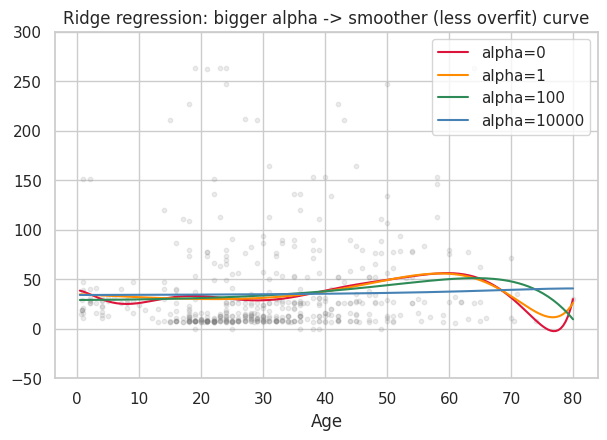

In [ ]:
fig, ax = plt.subplots(figsize=(7,4.5))
x_line = np.linspace(x.min(), x.max(), 200).reshape(-1,1)

for alpha, color in [(0, 'crimson'), (1, 'darkorange'), (100, 'seagreen'), (10000, 'steelblue')]:
    model = make_pipeline(PolynomialFeatures(15), StandardScaler(), Ridge(alpha=alpha if alpha>0 else 1e-10))
    model.fit(x_train.reshape(-1,1), y_train)
    ax.plot(x_line, model.predict(x_line), color=color, label=f'alpha={alpha}')

ax.scatter(x_train, y_train, alpha=0.15, s=10, color='gray')
ax.set_ylim(-50, 300); ax.legend(); ax.set_xlabel('Age')
ax.set_title('Ridge regression: bigger alpha -> smoother (less overfit) curve')
plt.show()

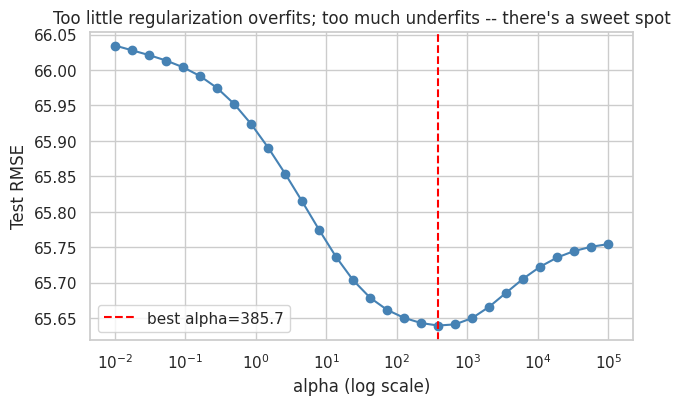

In [ ]:
alphas = np.logspace(-2, 5, 30)
test_rmses = []
for a in alphas:
    model = make_pipeline(PolynomialFeatures(15), StandardScaler(), Ridge(alpha=a))
    model.fit(x_train.reshape(-1,1), y_train)
    pred = model.predict(x_test.reshape(-1,1))
    test_rmses.append(np.sqrt(mean_squared_error(y_test, pred)))

plt.semilogx(alphas, test_rmses, marker='o', color='steelblue')
best_alpha = alphas[np.argmin(test_rmses)]
plt.axvline(best_alpha, color='red', linestyle='--', label=f'best alpha={best_alpha:.1f}')
plt.xlabel('alpha (log scale)'); plt.ylabel('Test RMSE'); plt.legend()
plt.title('Too little regularization overfits; too much underfits -- there\'s a sweet spot')
plt.show()

---
# 5. Regularization: Lasso (L1) and automatic feature selection

Lasso penalizes the **absolute value** of coefficients instead of their square:

$$\text{Lasso loss} = \text{SSE} + \alpha \sum_j |\beta_j|$$

This geometric difference has a striking practical consequence: Lasso can push coefficients to **exactly zero**, effectively performing feature selection (Week 5, Class 1) automatically as a side effect of fitting the model.

In [ ]:
multi_features = ['pclass', 'age', 'sibsp', 'parch']
Xm_train, Xm_test, ym_train, ym_test = train_test_split(df[multi_features], df['fare'], test_size=0.3, random_state=42)

scaler = StandardScaler().fit(Xm_train)
Xm_train_s, Xm_test_s = scaler.transform(Xm_train), scaler.transform(Xm_test)

coef_table = pd.DataFrame({'feature': multi_features})
for alpha in [0.01, 1, 10, 50]:
    lasso = Lasso(alpha=alpha).fit(Xm_train_s, ym_train)
    coef_table[f'alpha={alpha}'] = lasso.coef_.round(3)

print(coef_table)
print("\n-> As alpha grows, weaker features get pushed to exactly 0 first -- automatic feature selection.")

  feature  alpha=0.01  alpha=1  alpha=10  alpha=50
0  pclass     -30.535  -29.055   -19.351       0.0
1     age      -2.267   -0.978    -0.000       0.0
2   sibsp       6.198    5.810     0.000       0.0
3   parch      10.319    9.631     2.572       0.0

-> As alpha grows, weaker features get pushed to exactly 0 first -- automatic feature selection.


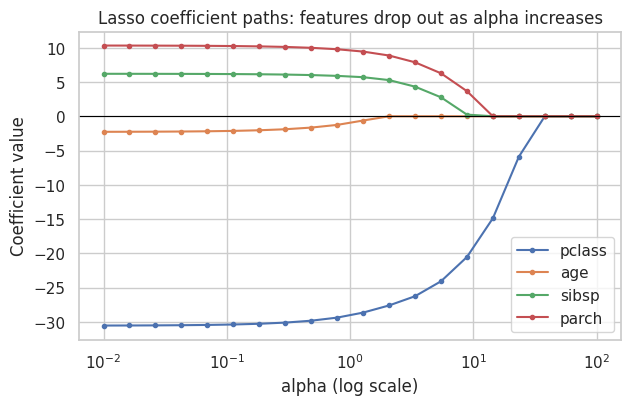

In [ ]:
alphas_l1 = np.logspace(-2, 2, 20)
coef_paths = np.array([Lasso(alpha=a).fit(Xm_train_s, ym_train).coef_ for a in alphas_l1])

for i, feat in enumerate(multi_features):
    plt.plot(alphas_l1, coef_paths[:, i], marker='.', label=feat)
plt.xscale('log'); plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('alpha (log scale)'); plt.ylabel('Coefficient value'); plt.legend()
plt.title('Lasso coefficient paths: features drop out as alpha increases')
plt.show()

---
# 6. ElasticNet & choosing the regularization strength

**ElasticNet** blends both penalties, controlled by a mixing parameter: Ridge's stability plus Lasso's feature-selection property. In practice, the right $\alpha$ (and mixing ratio) is chosen the same way we chose $k$ for KNN and depth for trees last class: via **cross-validation** (Week 5, Class 1), never by looking at test-set performance directly (that would leak test information into model selection).

In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5).fit(Xm_train_s, ym_train)
lasso_cv = LassoCV(alphas=np.logspace(-3, 3, 50), cv=5).fit(Xm_train_s, ym_train)
elastic_cv = ElasticNetCV(alphas=np.logspace(-3, 3, 50), l1_ratio=[.1,.5,.7,.9,1], cv=5).fit(Xm_train_s, ym_train)

for name, model in [('Ridge', ridge_cv), ('Lasso', lasso_cv), ('ElasticNet', elastic_cv)]:
    test_r2 = r2_score(ym_test, model.predict(Xm_test_s))
    print(f"{name:12s} best_alpha={model.alpha_:.3f}  test R2={test_r2:.3f}")

Ridge        best_alpha=8.286  test R2=0.214
Lasso        best_alpha=0.001  test R2=0.214
ElasticNet   best_alpha=0.013  test R2=0.214


---
# 7. Exercises

1. Rerun the polynomial degree comparison (Section 1) using `fare` predicted from `sibsp` instead of `age`. Does the same underfit/overfit pattern appear?
2. Produce a learning curve (Section 3) for a **degree-4** polynomial. Does it look more like the degree-1 or degree-15 curve's shape?
3. Using the `coef_table` from Section 5, identify which feature survives the longest (drops to zero at the highest alpha). What does that suggest about its importance for predicting fare?
4. Fit `Ridge`, `Lasso`, and plain `LinearRegression` all on `multi_features`, and compare their test R² at a fixed, moderate alpha (e.g. 1.0). Which performs best here, and why might that be (hint: think about how many features there are, and whether they're all useful)?
5. **Challenge**: `RidgeCV`, `LassoCV`, and `ElasticNetCV` all pick their alpha via cross-validation automatically. Manually recreate `LassoCV`'s choice by running a 5-fold cross-validation loop yourself over `alphas_l1`, and confirm you get the same `alpha_`.
